In [1]:
"""Lunar Lander : train a Lunar Lander, to land correctly on the moon."""
from pprint import pprint
from typing import NamedTuple

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
from huggingface_sb3 import load_from_hub, package_to_hub
from huggingface_hub import notebook_login 
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import VecEnv, make_vec_env
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from torch import nn, Tensor
from torch.distributions import Categorical
from torch.optim import AdamW

# How Gymnasium Works

- We create our environment using `gym.make()`
- We reset the environment to its initial state with `env.reset()`

Then, at each step
- Get an action using our model
- Using `env.step(action)`, we perform this action in the environment and get:
    - `observation` : The new state (st+1)
    - `reward` : The reward we get after executing the action
    - `terminated` : Indicates if the episode terminated (agent reach the terminal state)
    - `truncated` : Indicates a time limit or if an agent go out of bounds of the environment
    - `info` : A dictionary that provides additional information (depends on the environment)

In [2]:
# First, we create our environment called LunarLander-v2
env = gym.make("LunarLander-v2")

# Then we reset this environment
observation, info = env.reset()

# see what the Environment looks like
# The observation is a vector of size 8
# each value contains different information about the lander
print("Observation Space Shape", env.observation_space.shape)

# Get a random observation
observations = env.observation_space.sample()
obs_fields = [
    "x",
    "y", 
    "x_velocity",
    "y_velocity",
    "angle",
    "angular_velocity",
    "left_leg_contact",
    "right_leg_contact"
]
print("Sample observation: ")
pprint(
    dict(zip(obs_fields, env.observation_space.sample(), strict=True)),
    sort_dicts=False
)

# The action space is a discrete space of 4 possible actions
print("\nAction Space Shape", env.action_space.n)
actions = [
    "Do nothing",
    "Fire left orientation engine",
    "Fire main engine",
    "Fire right orientation engine"
]
for i in range(20):
    # Get a random action
    action = env.action_space.sample()

    # Perform the action
    print(f"Step {i:>2} : {actions[action]}")
    observation, reward, terminated, truncated, info = env.step(action)

    # If the game is terminated (in our case we land, crashed) or truncated (timeout)
    if terminated or truncated:
        # Reset the environment
        print("Environment is reset")
        observation, info = env.reset()

env.close()

Observation Space Shape (8,)
Sample observation: 
{'x': 0.6966052,
 'y': 20.54305,
 'x_velocity': -3.2071521,
 'y_velocity': 4.845523,
 'angle': -1.8174725,
 'angular_velocity': 4.196566,
 'left_leg_contact': 0.06784785,
 'right_leg_contact': 0.2543544}

Action Space Shape 4
Step  0 : Do nothing
Step  1 : Fire main engine
Step  2 : Do nothing
Step  3 : Fire left orientation engine
Step  4 : Do nothing
Step  5 : Fire main engine
Step  6 : Fire main engine
Step  7 : Fire main engine
Step  8 : Fire left orientation engine
Step  9 : Fire right orientation engine
Step 10 : Fire right orientation engine
Step 11 : Fire right orientation engine
Step 12 : Fire left orientation engine
Step 13 : Fire main engine
Step 14 : Fire main engine
Step 15 : Fire right orientation engine
Step 16 : Fire right orientation engine
Step 17 : Fire right orientation engine
Step 18 : Fire left orientation engine
Step 19 : Do nothing


## Reward function

After every step a reward is granted. The total reward of an episode is the sum of the rewards for all the steps within that episode.

For each step, the reward:
- Is increased/decreased the closer/further the lander is to the landing pad.
- Is increased/decreased the slower/faster the lander is moving.
- Is decreased the more the lander is tilted (angle not horizontal).
- Is increased by 10 points for each leg that is in contact with the ground.
- Is decreased by 0.03 points each frame a side engine is firing.
- Is decreased by 0.3 points each frame the main engine is firing.
- The episode receive an additional reward of -100 or +100 points for crashing or landing safely respectively.

An episode is considered a solution if it scores at least 200 points.

## Vectorized Environment
We create a vectorized environment (stack multiple independent environments into a single environment), this way, we’ll have more diverse experiences during the training.

In [4]:
n_envs = 10
vec_env = make_vec_env("LunarLander-v2", n_envs=n_envs)

observations = []
actions = []
rewards = []

# Restart the environment and get initial observation
observations.append(vec_env.reset())
while True:
    # Sample random actions
    acts_i = torch.randint(0, 4, (n_envs,)).numpy()
    actions.append(acts_i)

    # Perform the actions
    next_obs, rewards_i, done_i, info = vec_env.step(acts_i)
    rewards.append(rewards_i)

    if done_i.any():
        break

    observations.append(next_obs)

observations = torch.from_numpy(np.array(observations))
actions = torch.from_numpy(np.array(actions))
rewards = torch.from_numpy(np.array(rewards))

vec_env.close()

print("Observations shape:", observations.shape)
print("Actions shape:", actions.shape)
print("Rewards shape:", rewards.shape)

Observations shape: torch.Size([69, 10, 8])
Actions shape: torch.Size([69, 10])
Rewards shape: torch.Size([69, 10])


# Simple Policy Network

## Policy Network

In [5]:
class PolicyNet(nn.Module):
    """Simple policy network."""

    def __init__(
        self,
        obs_dim: int,
        act_dim: int,
        hidden_dim: int,
        obs_mean: Tensor | None = None,
        obs_std: Tensor | None = None,
    ) -> None:
        super().__init__()

        self.obs_dim = obs_dim
        self.act_dim = act_dim
        self.obs_mean = nn.Parameter(obs_mean) if obs_mean is not None else None
        self.obs_std = nn.Parameter(obs_std) if obs_mean is not None else None

        # Define the policy network
        self.pi = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ELU(),
            nn.Linear(hidden_dim, act_dim),
        )

    def forward(self, observation: Tensor) -> Tensor:
        """Get logits for action space given an observation.

        Parameters
        ----------
        observation: Tensor[..., obs_dim, dtype=float32]
            Observation tensor.

        Returns
        -------
        action_logits: Tensor[..., act_dim, dtype=float32]
            Logits for action space.
        """
        observation = torch.atleast_2d(observation)
        if self.obs_mean is not None:
            observation = (observation - self.obs_mean) / (self.obs_std + 1e-6)
        return self.pi(torch.atleast_2d(observation))

    def get_policy(self, observation: Tensor) -> Categorical:
        """Compute probability distribution over actions given an observation.

        Parameters
        ----------
        observation: Tensor[..., obs_dim, dtype=float32]
            Observation tensor.

        Returns
        -------
        policy: Categorical
            Action distribution given the observation.
        """
        logits = self.forward(observation)
        return Categorical(logits=logits)

    def get_action(self, observation: Tensor) -> Tensor:
        """Sample an action from the policy given an observation.

        Parameters
        ----------
        observation : Tensor[..., obs_dim, dtype=float32]
            Observation tensor.

        Returns
        -------
        action: Tensor[..., dtype=int64]
            Sampled action.
        """
        return self.get_policy(observation).sample()

    def predict(
        self,
        observation: np.ndarray,
        state: tuple[np.ndarray, ...] | None = None,
        episode_start: np.ndarray | None = None,
        deterministic: bool = False,
    ) -> tuple[np.ndarray, None]:
        """Predict action given an observation."""
        observation = torch.as_tensor(observation, dtype=torch.float32)
        # if deterministic:
        #     logits = self.forward(observation)
        #     action = logits.argmax(dim=-1).numpy()
        # else:
        #     action = self.get_action(observation).numpy()
        action = self.get_action(observation).numpy()
        return action, state

# Create a policy network
model = PolicyNet(
    obs_dim=vec_env.observation_space.shape[0],
    act_dim=vec_env.action_space.n,
    hidden_dim=64
)

model

PolicyNet(
  (pi): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (2): ELU(alpha=1.0)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (5): ELU(alpha=1.0)
    (6): Linear(in_features=64, out_features=64, bias=True)
    (7): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (8): ELU(alpha=1.0)
    (9): Linear(in_features=64, out_features=4, bias=True)
  )
)

In [6]:
model.eval()
eval_env = Monitor(gym.make("LunarLander-v2"))
mean_reward, std_reward = evaluate_policy(
    model, eval_env, n_eval_episodes=10, deterministic=True
)
print(f"mean_reward={mean_reward:.2f} +/- {std_reward}")

mean_reward=-368.01 +/- 167.4761254151377


In [7]:
# Test model on a batch of observations
print(f"Observations shape: {observations.shape}")

# Get a sample of actions | observations
actions = model.get_action(observations)
print(f"Actions shape: {actions.shape}")

# Get the action distribution
action_dist = model.get_policy(observations)
print(f"Action distribution: {action_dist}")

# Get the log probability of the actions taken
logp: Tensor = action_dist.log_prob(value=actions)
print(f"Action log-probability shape: {logp.shape}")

Observations shape: torch.Size([69, 10, 8])
Actions shape: torch.Size([69, 10])
Action distribution: Categorical(logits: torch.Size([69, 10, 4]))
Action log-probability shape: torch.Size([69, 10])


## Loss function

In [8]:
def compute_loss(
    model: PolicyNet,
    observations: Tensor,
    actions: Tensor,
    weights: Tensor
) -> Tensor:
    """Compute the policy gradient loss from a batch of (obs, action, weight) tuples.

    - the (obs, action, weight) tuples are collected while acting according
    to the current policy over the course of an episode (or several episodes).
    - the weight for a observation-action pair is the return from the episode
    to which it belongs.

    Parameters
    ----------
    model: PolicyNet
        The policy network
    observations: Tensor[..., obs_dim, dtype=float32]
        A batch of observations
    actions: Tensor[..., dtype=int64]
        A batch of actions
    weights: Tensor[..., dtype=float32]
        Episode return for each state-action pair.

    Returns
    -------
    Tensor[1]
        The policy gradient loss
    """
    # Validate the shape of inputs
    if observations.shape[:-1] != actions.shape:
        raise ValueError("# Observations must match # actions")
    if observations.shape[:-1] != weights.shape:
        raise ValueError("# Observations must match # weights")

    # Get action probability distribution given observation
    action_dist = model.get_policy(observations)

    # Compute log probability of the action
    logp: Tensor = action_dist.log_prob(value=actions)

    # Compute the policy gradient loss
    return -(logp * weights).mean()

In [9]:
def get_reward_to_go_weights(rewards: Tensor) -> Tensor:
    """Compute the reward-to-go weights from a batch of rewards.

    Rewards obtained before taking an action have no bearing on how good
    that action was; only rewards that come after.

    Parameters
    ----------
    rewards: Tensor[n_steps, n_envs, dtype=float32]
        A sequence of rewards from an episode (per environment).

    Returns
    -------
    Tensor[..., dtype=float32]
        The reward-to-go weights for each step in the sequence.

    Example
    -------
    >>> import torch
    >>> rewards = torch.tensor(
    ...     [[ 2.4491,  1.2703], [-0.9930, -0.8285], [3.4893, -5.6373]]
    ... )
    >>> get_reward_to_go_weights(rewards)
    tensor([[ 4.9454, -5.1955],
            [ 2.4963, -6.4658],
            [ 3.4893, -5.6373]])
    """
    # Compute the reward-to-go weights
    return rewards.flip(dims=(0,)).cumsum(dim=0).flip(dims=(0,))

In [10]:
# Compute the reward-to-go weights
weights = get_reward_to_go_weights(rewards)

# Compute the policy gradient loss
loss = compute_loss(model, observations, actions, weights)
print(f"Policy gradient loss: {loss}")

Policy gradient loss: -47.776634216308594


## Train the policy network

In [11]:
class EpisodeData(NamedTuple):
    """Sequence of observations, actions, and rewards from an episode.

    Attributes
    ----------
    num_steps: np.ndarray[n_envs, dtype=int64]
        Number of steps in the episode for each environment.
    observations: Tensor[n_steps, n_envs, obs_dim, dtype=float32]
        Sequence of observations from the episode.
    actions: Tensor[n_steps, n_envs, dtype=int64]
        Sequence of actions from the episode.
    rewards: Tensor[n_steps, n_envs, dtype=float32]
        Sequence of rewards from the episode.
    """

    num_steps: np.ndarray
    observations: Tensor
    actions: Tensor
    rewards: Tensor


class EpisodeSummary(NamedTuple):
    """Summary of an episode.

    Attributes
    ----------
    num_steps: np.ndarray
        Number of steps in the episode for each environment.
    total_rewards: np.ndarray
        Total rewards for each environment in the episode.
    """

    num_steps: np.ndarray
    total_rewards: np.ndarray


def collect_episode_data(
    env: VecEnv,
    model: PolicyNet | None,
    max_steps: int | None,
    device: torch.device,
) -> EpisodeData:
    """Collect observations, actions, and rewards over an episode."""
    # Reset environment and get initial observation
    obs = env.reset()

    # Collect observations, actions, and rewards over the episode
    num_steps = np.zeros(env.num_envs)
    completed = np.zeros(env.num_envs, dtype=bool)
    observations = []
    actions = []
    rewards = []
    while not completed.all():
        num_steps[~completed] += 1

        # Convert observation to tensor and move to device
        obs = torch.from_numpy(obs).to(device)
        observations.append(obs)

        if model is None:
            # sample random actions
            act = torch.randint(
                low=0,
                high=vec_env.action_space.n,
                size=(vec_env.num_envs,),
                dtype=torch.int64,
                device=device
            )
        else:
            # get actions given observations
            act = model.get_action(obs)
        actions.append(act)

        # Perform the actions
        obs, reward, done, _ = env.step(act.cpu().numpy())

        # Zero out rewards for completed environments
        reward[completed] = 0

        # Store the rewards
        rewards.append(torch.from_numpy(reward).to(device))

        # Update the completed environments
        completed = np.logical_or(completed, done)

        if max_steps is not None and num_steps.max() >= max_steps:
            break

    # Stack episode steps together into a batch
    return EpisodeData(
        num_steps=num_steps,
        observations=torch.stack(observations, dim=0),
        actions=torch.stack(actions, dim=0),
        rewards=torch.stack(rewards, dim=0)
    )


def train_for_one_episode(
    env: VecEnv,
    model: PolicyNet,
    optimizer: torch.optim.Optimizer,
    *,
    max_steps: int = 300,
    device: torch.device = torch.device("cpu"),
) -> EpisodeSummary:
    """Train the policy network for one episode.

    Parameters
    ----------
    env: VecEnv
        The environment
    model: PolicyNet
        The policy network
    optimizer: torch.optim.Optimizer
        The optimizer
    device: torch.device, optional
        The device to run the training on.
        (default = "cpu")
    max_steps: int, optional
        Maximum number of steps to run the episode.
        (default = 300)

    Returns
    -------
    EpisodeSummary
        Summary of the episode.
    """
    # Collect episode data
    episode_data = collect_episode_data(env, model, max_steps, device)

    # Compute the reward-to-go weights
    weights = get_reward_to_go_weights(episode_data.rewards)

    # Optimize the policy network
    optimizer.zero_grad()
    loss = compute_loss(model, episode_data.observations, episode_data.actions, weights)
    loss.backward()
    optimizer.step()

    # Return the episode summary
    return EpisodeSummary(
        num_steps=episode_data.num_steps,
        total_rewards=episode_data.rewards.sum(0).cpu().numpy(),
    )

In [12]:
# Initialize vectorized environment
n_envs = 128
vec_env = make_vec_env("LunarLander-v2", n_envs=n_envs)

# Collect episode data from a random policy
episode_data = collect_episode_data(vec_env, None, None, torch.device("cpu"))

# Create a policy network
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print (f"Using device: {device}")
simple_model = PolicyNet(
    obs_dim=vec_env.observation_space.shape[0],
    act_dim=vec_env.action_space.n,
    hidden_dim=16,
    obs_mean=episode_data.observations.mean(dim=(0, 1)),
    obs_std=episode_data.observations.std(dim=(0, 1)),
)
simple_model.to(device)

# Create an optimizer
learning_rate = 1e-2
learning_rate_decay = 0.99
optimizer = AdamW(simple_model.parameters(), lr=learning_rate)

Using device: cuda


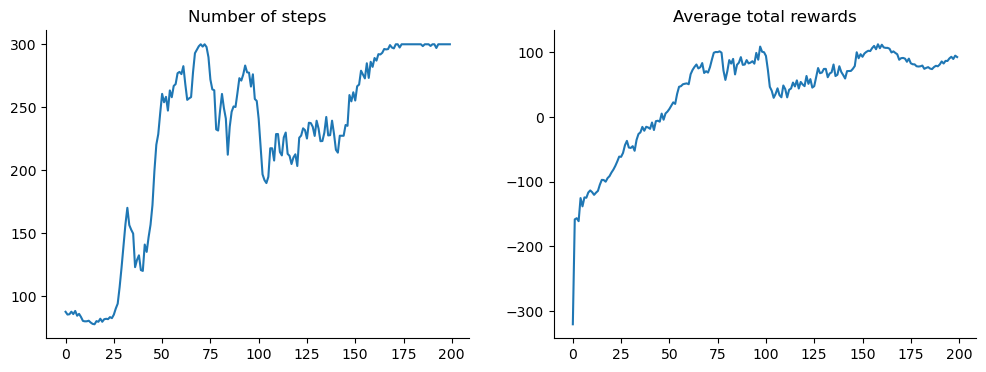

In [13]:
num_episodes = 200
max_steps = 300

num_steps = []
total_rewards = []
for episode in range(num_episodes):
    episode_summary = train_for_one_episode(
        vec_env, simple_model, optimizer, device=device, max_steps=max_steps
    )
    num_steps.append(episode_summary.num_steps.mean())
    total_rewards.append(episode_summary.total_rewards.mean())

    # Decay learning rate
    learning_rate *= learning_rate_decay
    for param_group in optimizer.param_groups:
        param_group["lr"] = learning_rate

    # Report progress
    print(
        f"Episode {episode:>6,} | "
        f"avg # steps: {np.mean(num_steps[-30:]):>5.0f} | "
        f"avg total reward: {np.median(total_rewards[-30:]):>5.1f}",
        flush=True,
        end="\r"
    )

_, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(num_steps)
axs[0].set_title("Number of steps")
axs[0].spines["right"].set_visible(False)
axs[0].spines["top"].set_visible(False)

axs[1].plot(total_rewards)
axs[1].set_title("Average total rewards")
axs[1].spines["right"].set_visible(False)
axs[1].spines["top"].set_visible(False)

In [14]:
simple_model.eval().cpu()
eval_env = Monitor(gym.make("LunarLander-v2"))
mean_reward, std_reward = evaluate_policy(
    simple_model, eval_env, n_eval_episodes=10, deterministic=True
)
print(f"mean_reward={mean_reward:.2f} +/- {std_reward}")

mean_reward=-24.58 +/- 20.011981185312944


## Capture replay

In [15]:
def capture_replay(
    model: PolicyNet, n_steps: int = 200
) -> tuple[list[np.ndarray], list[float]]:
    """Capture a replay of the model's interaction with the environment."""
    # Initialize the environment
    env = gym.make("LunarLander-v2", render_mode="rgb_array")

    # Reset the environment
    obs, *_ = env.reset()

    # Capture the replay
    frames = []
    rewards = []
    for _ in range(n_steps):
        # Store the frame
        frames.append(env.render())

        # get action | obs
        act = model.get_action(torch.from_numpy(obs))

        # Perform the actions
        obs, reward, terminated , truncated, _ = env.step(act.item())
        rewards.append(reward)

        # Check if any of the environments have reach end of episode
        if terminated or truncated:
            break

    # Close the environment
    env.close()

    return frames, rewards

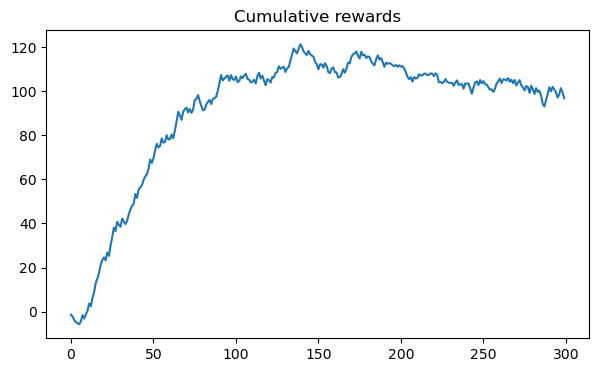

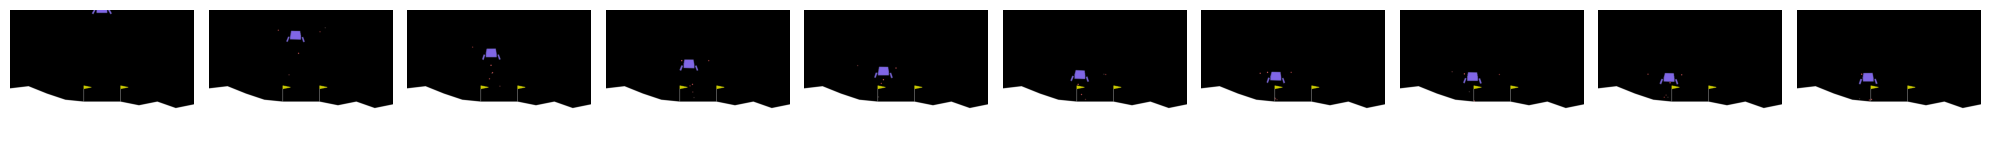

In [26]:
frames, rewards = capture_replay(simple_model, 300)

# Plot cumulative rewards over episode
_, ax  = plt.subplots(1, 1, figsize=(7, 4))
ax.plot(np.cumsum(rewards))
ax.set_title("Cumulative rewards")

# plot a sample of the replay
num_cols = 10
frame_idxs = np.linspace(0, len(rewards) - 1, num_cols).astype(int)
fig, axs = plt.subplots(1, num_cols, figsize=(20, 5))
for i in range(num_cols):
    frame_idx = frame_idxs[i]
    frame = frames[frame_idx]
    axs[i].imshow(frame)
    axs[i].axis("off")
plt.tight_layout()

#  Proximal Policy Optimization

In [23]:
env = gym.make("LunarLander-v2")

ppo_model = PPO(
    policy="MlpPolicy",
    env=env,
    n_steps=1024,
    batch_size=64,
    n_epochs=4,
    gamma=0.999,
    gae_lambda=0.98,
    ent_coef=0.01,
    verbose=0,
)

eval_env = Monitor(gym.make("LunarLander-v2"))
mean_reward, std_reward = evaluate_policy(
    ppo_model, eval_env, n_eval_episodes=10, deterministic=True
)
print(f"mean_reward={mean_reward:.2f} +/- {std_reward}")

mean_reward=-629.21 +/- 131.10476612339087


In [24]:
ppo_model.learn(total_timesteps=1_000_000)

eval_env = Monitor(gym.make("LunarLander-v2"))
mean_reward, std_reward = evaluate_policy(
    ppo_model, eval_env, n_eval_episodes=10, deterministic=True
)
print(f"mean_reward={mean_reward:.2f} +/- {std_reward}")

mean_reward=218.89 +/- 63.52968149247611
